# 📊 Avaliação de Modelo Fine-Tuned com LoRA do Modelo baseado em unicamp-dl/ptt5-v2-base

Este notebook avalia um modelo de linguagem fine-tuned usando as principais métricas de NLP. O dataset utilizado manual de NR 12 (`dataset.jsonl`) e o modelo base é o `unicamp-dl/ptt5-v2-base` com adaptadores LoRA.

---

## 🗺️ Métricas Avaliadas

| Métrica | Foco | Intervalo Típico |
|---|---|---|
| **Perplexidade (PPL)** | Capacidade preditiva do modelo | Menor = melhor |
| **BLEU** | Precisão de n-gramas vs. referência | 0–100 (maior = melhor) |
| **ROUGE** | Recall de sobreposição de conteúdo | 0–1 (maior = melhor) |
| **Fidelidade (Faithfulness)** | Se a resposta é fiel ao contexto | 0–1 (maior = melhor) |
| **Relevância da Resposta** | Se a resposta é útil à pergunta | 0–1 (maior = melhor) |
| **Aderência ao Plano** | Se o agente segue o plano de ação | 0–1 (maior = melhor) |

---

## 1 — Instalação e Importação

Instalamos todas as bibliotecas necessárias.

In [2]:
# ============================================================
#  INSTALAÇÃO DE DEPENDÊNCIAS
# ============================================================

!pip install -q transformers peft torch sacrebleu rouge-score nltk pandas \
             matplotlib seaborn tqdm

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print('✅ Todas as dependências instaladas com sucesso!')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.1 MB/s eta 0:00:00
✅ Todas as dependências instaladas com sucesso!


In [3]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    !pip install --upgrade torchao>=0.16.0

In [4]:
# ============================================================
#  IMPORTAÇÕES
# ============================================================

import json
import math
import re
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from tqdm import tqdm

# Transformers & PEFT
#from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from peft import PeftModel

# Métricas NLP
from sacrebleu.metrics import BLEU
from rouge_score import rouge_scorer
from nltk.tokenize import word_tokenize

warnings.filterwarnings('ignore')

# Configuração de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('✅ Importações concluídas!')
print(f'   PyTorch: {torch.__version__}')
print(f'   Dispositivo disponível: {"GPU (CUDA)" if torch.cuda.is_available() else "CPU"}')

✅ Importações concluídas!
   PyTorch: 2.11.0+cu128
   Dispositivo disponível: GPU (CUDA)


## 📂 2 — Carregamento do Dataset

Lemos o arquivo `dataset.jsonl`. Cada linha contém:
- **`instruction`**: o que o usuário quer saber
- **`input`**: contexto adicional (veículo, modelo, etc.)
- **`output`**: resposta esperada (ground truth)

In [5]:
DATASET_PATH = '/content/dataset.jsonl'
samples = []
with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            samples.append(json.loads(line))

print(f'✅ Dataset carregado com {len(samples)} amostras.\n')

# Exibição amigável das primeiras amostras
df_raw = pd.DataFrame(samples)
df_raw[['Instruction', 'Output']].head(3).style \
    .set_caption('📋 Primeiras amostras do dataset') \
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})

✅ Dataset carregado com 416 amostras.



,Instruction,Output
0,Qual é a principal característica técnica abordada no manual para sistemas de comandos de segurança?,"O manual aborda principalmente as características técnicas necessárias para o projeto e instalação de sistemas de comandos de segurança em máquinas e equipamentos, enfocando tanto sistemas simples quanto redundantes com dois canais, conforme a Norma Regulamentadora nº 12 (NR-12)."
1,Quais são as condições para a redundância dos dispositivos de segurança em circuitos elétricos de chave de partida?,"Para a redundância dos dispositivos de segurança em circuitos elétricos de chave de partida, conforme a NR-12, os dispositivos devem possuir estrutura redundante (item 12.4.14) e permitir que as falhas que comprometam a função de segurança sejam monitoradas."
2,Como as máquinas devem ser dimensionadas de acordo com a NR-12?,"As máquinas devem ser adequadamente dimensionadas em conformidade com as normas técnicas oficiais ou as normas internacionais aplicáveis, conforme estabelecido na NR-12."


## 🤖 Célula 4 — Carregamento do Modelo Fine-Tuned

Carregamos o modelo base `unicamp-dl/ptt5-v2-base` e aplicamos os adaptadores LoRA salvos em `lora_finetuned_model/`.

In [6]:
# ============================================================
#  CARREGAMENTO DO MODELO FINE-TUNED (LoRA)
# ============================================================

MODEL_BASE      = 'unicamp-dl/ptt5-v2-base'
LORA_MODEL_PATH = 'lora_finetuned_model'    # mesmo diretório gerado pelo lora_modelo_ptt5
TOKENIZER_PATH  = 'ptt5_tokenizer'           # nome salvo pelo lora_modelo_ptt5
base_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_BASE)

print('⏳ Carregando tokenizer...')
finetuned_tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_PATH)

if finetuned_tokenizer.pad_token is None:
    finetuned_tokenizer.pad_token = finetuned_tokenizer.eos_token
    print('   ⚠️  pad_token não encontrado — usando eos_token como pad_token.')

print('⏳ Carregando modelo base...')

print('⏳ Aplicando adaptadores LoRA...')
finetuned_model = PeftModel.from_pretrained(base_model, LORA_MODEL_PATH)
finetuned_model.eval()  # Modo de inferência (desativa dropout)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
finetuned_model = finetuned_model.to(DEVICE)

# Contagem de parâmetros
total_params    = sum(p.numel() for p in finetuned_model.parameters())
trainable_params = sum(p.numel() for p in finetuned_model.parameters() if p.requires_grad)

print(f'\n✅ Modelo carregado no dispositivo: {DEVICE}')
print(f'   Parâmetros totais   : {total_params:,}')
print(f'   Parâmetros LoRA     : {trainable_params:,}')
print(f'   Redução LoRA        : {(1 - trainable_params/total_params)*100:.1f}% do total')

config.json:   0%|          | 0.00/731 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

⏳ Carregando tokenizer...


model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

⏳ Carregando modelo base...
⏳ Aplicando adaptadores LoRA...

✅ Modelo carregado no dispositivo: cuda
   Parâmetros totais   : 224,673,024
   Parâmetros LoRA     : 0
   Redução LoRA        : 100.0% do total


## 4 — Função de Geração de Respostas

Definimos a função central que constrói o **prompt** e chama o modelo para gerar uma resposta.

In [7]:
def build_prompt(instruction: str, input_text: str = '') -> str:
    """Monta a instrução para o encoder do mT5."""
    if input_text.strip():
        return f"Instruction: {instruction}\nInput: {input_text}"
    return f"Instruction: {instruction}"


def generate_response(
    model,
    tokenizer,
    instruction: str,
    input_text: str = '',
    max_new_tokens: int = 200,
    temperature: float = 0.7,
    top_p: float = 0.9,
) -> str:
    prompt = build_prompt(instruction, input_text)
    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=192,         # MAX_INPUT_LENGTH do lora_modelo_ptt5
    ).to(DEVICE)

    with torch.no_grad():
        output_ids = model.generate(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=top_p,
            do_sample=True,
            # Seq2Seq: NÃO passar pad_token_id nem eos_token_id aqui
            # o mT5 gerencia decoder_start_token_id internamente
        )

    # No Seq2Seq a saída já é SÓ a resposta — sem prompt embutido
    return tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()

print('✅ Funções de geração definidas!')

# --- TESTE RÁPIDO ---
sample = samples[0]
test_response = generate_response(
    finetuned_model, finetuned_tokenizer,
    sample['Instruction'] # Corrigido: 'instruction' para 'Instruction', e 'input' removido
)
print(f'\n🧪 Teste rápido com a primeira amostra:')
print(f'   📌 Instrução : {sample["Instruction"]}') # Corrigido: 'instruction' para 'Instruction'
# Removida a linha de contexto, pois a chave 'input' não existe nos dados de amostra
print(f'   ✅ Esperado  : {sample["Output"][:80]}...') # Corrigido: 'output' para 'Output'
print(f'   🤖 Gerado    : {test_response[:80]}...')

✅ Funções de geração definidas!

🧪 Teste rápido com a primeira amostra:
   📌 Instrução : Qual é a principal característica técnica abordada no manual para sistemas de comandos de segurança?
   ✅ Esperado  : O manual aborda principalmente as características técnicas necessárias para o pr...
   🤖 Gerado    : A característica técnica abordada no manual é a função de intertravamento e cone...


## 5 — Métrica 1: Perplexidade (PPL)

### O que é?
A **Perplexidade** mede o quão surpreso o modelo fica ao ver o texto de referência. É calculada a partir da **log-verossimilhança negativa média** por token:

$$\text{PPL} = \exp\left(-\frac{1}{N}\sum_{i=1}^{N} \log P(w_i | w_1, \dots, w_{i-1})\right)$$

- **PPL baixa** → o modelo prevê bem o texto de referência → melhor desempenho.
- **PPL = 1** → previsão perfeita (impossível na prática).
- **PPL alta** → o modelo está "confuso" com o texto.

### Como é calculada aqui?
Para cada amostra, passamos o **texto de referência** (output esperado) pelo modelo e calculamos a loss (cross-entropy), depois convertemos para PPL.

In [8]:
def compute_perplexity_for_sample(
    model, tokenizer, instruction: str, input_text: str, reference: str
) -> float:
    """
    Calcula PPL para um modelo Seq2Seq (mT5):
    - O encoder recebe a instrução (source)
    - Os labels são os tokens da referência (target)
    - A loss é calculada sobre os tokens do decoder
    """
    prompt = build_prompt(instruction, input_text)

    # Encoder: tokeniza a instrução
    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=192,
    ).to(DEVICE)

    # Decoder labels: tokeniza a referência
    labels = tokenizer(
        reference,
        return_tensors='pt',
        truncation=True,
        max_length=128,
    ).to(DEVICE)

    label_ids = labels['input_ids']
    # Substitui padding por -100 para ignorar na loss
    label_ids[label_ids == tokenizer.pad_token_id] = -100

    with torch.no_grad():
        outputs = model(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            labels=label_ids,
        )
        loss = outputs.loss

    return math.exp(loss.item())

# Calcula PPL para todas as amostras
print('⏳ Calculando Perplexidade para todas as amostras...')
ppl_scores = []
for s in tqdm(samples, desc='PPL'):
    ppl = compute_perplexity_for_sample(
        finetuned_model, finetuned_tokenizer,
        s['Instruction'], '', s['Output'] # Corrigido: 'instruction' para 'Instruction', 'input' removido, 'output' para 'Output'
    )
    ppl_scores.append(ppl)

mean_ppl = np.mean(ppl_scores)
print(f'\n📊 Perplexidade Média : {mean_ppl:.2f}')
print(f'   Mínima            : {min(ppl_scores):.2f}  (amostra mais fácil)')
print(f'   Máxima            : {max(ppl_scores):.2f}  (amostra mais difícil)')
print(f'\n💡 Interpretação: PPL = {mean_ppl:.1f} significa que, em média,')
print(f'   o modelo considera ~{mean_ppl:.0f} próximas palavras igualmente prováveis.')

⏳ Calculando Perplexidade para todas as amostras...



PPL: 100%|██████████| 416/416 [00:34<00:00, 11.93it/s]


📊 Perplexidade Média : 6.26
   Mínima            : 1.38  (amostra mais fácil)
   Máxima            : 36.34  (amostra mais difícil)

💡 Interpretação: PPL = 6.3 significa que, em média,
   o modelo considera ~6 próximas palavras igualmente prováveis.


## 6 — Métrica 2: BLEU

### O que é?
O **BLEU** (Bilingual Evaluation Understudy) mede a **precisão de n-gramas** entre o texto gerado e uma referência.

$$\text{BLEU} = \text{BP} \cdot \exp\left(\sum_{n=1}^{N} w_n \log p_n\right)$$

onde:
- $p_n$ = precisão de n-gramas (1-gram, 2-gram, 3-gram, 4-gram)
- **BP** = Brevity Penalty (penaliza respostas muito curtas)
- Escala de 0 a 100 (ou 0 a 1)

### Limitações
BLEU foca em **precisão** — se todos os n-gramas gerados aparecem na referência. Ele não captura bem paráfrases ou sinônimos.

In [9]:
# ============================================================
#  MÉTRICA 2 — BLEU
# ============================================================

def compute_bleu(hypotheses: list, references: list) -> dict:
    """
    Calcula BLEU usando sacrebleu.

    Parâmetros
    ----------
    hypotheses : list[str]   — textos gerados pelo modelo
    references : list[str]   — textos de referência (ground truth)

    Retorna
    -------
    dict com score geral e scores por n-grama
    """
    bleu = BLEU(effective_order=True)
    # sacrebleu espera: hyps = list[str], refs = list[list[str]]
    result = bleu.corpus_score(hypotheses, [references])

    return {
        'bleu_score' : result.score,
        '1-gram'     : result.precisions[0],
        '2-gram'     : result.precisions[1],
        '3-gram'     : result.precisions[2],
        '4-gram'     : result.precisions[3],
        'brevity_penalty': result.bp,
    }


# Gera todas as respostas
print('⏳ Gerando respostas do modelo para calcular BLEU...')
generated_responses = []
reference_outputs   = []

for s in tqdm(samples, desc='Gerando'):
    gen = generate_response(
        finetuned_model, finetuned_tokenizer,
        s['Instruction'], '' # Corrigido: 'instruction' para 'Instruction', e 'input' removido
    )
    generated_responses.append(gen)
    reference_outputs.append(s['Output']) # Corrigido: 'output' para 'Output'

bleu_results = compute_bleu(generated_responses, reference_outputs)

print(f'\n📊 Resultados BLEU:')
print(f'   BLEU Score (corpus)  : {bleu_results["bleu_score"]:.2f}')
print(f'   Precisão 1-gram      : {bleu_results["1-gram"]:.2f}%')
print(f'   Precisão 2-gram      : {bleu_results["2-gram"]:.2f}%')
print(f'   Precisão 3-gram      : {bleu_results["3-gram"]:.2f}%')
print(f'   Precisão 4-gram      : {bleu_results["4-gram"]:.2f}%')
print(f'   Brevity Penalty      : {bleu_results["brevity_penalty"]:.4f}')
print(f'\n💡 BLEU > 30 é geralmente considerado bom para geração de texto.')

⏳ Gerando respostas do modelo para calcular BLEU...


Gerando: 100%|██████████| 416/416 [06:52<00:00,  1.01it/s]


📊 Resultados BLEU:
   BLEU Score (corpus)  : 15.64
   Precisão 1-gram      : 42.90%
   Precisão 2-gram      : 21.37%
   Precisão 3-gram      : 15.18%
   Precisão 4-gram      : 11.32%
   Brevity Penalty      : 0.7850

💡 BLEU > 30 é geralmente considerado bom para geração de texto.


## 7 — Métrica 3: ROUGE

### O que é?
**ROUGE** (Recall-Oriented Understudy for Gisting Evaluation) complementa o BLEU focando no **recall** — quanta informação da referência aparece na resposta gerada.

| Variante | O que mede |
|---|---|
| **ROUGE-1** | Sobreposição de unigramas (palavras individuais) |
| **ROUGE-2** | Sobreposição de bigramas (pares de palavras) |
| **ROUGE-L** | Subsequência Comum mais Longa (LCS) — captura ordem |

Cada métrica retorna **Precisão**, **Recall** e **F1** (harmônica entre os dois).

In [10]:
# ============================================================
#  MÉTRICA 3 — ROUGE
# ============================================================

def compute_rouge_scores(hypotheses: list, references: list) -> pd.DataFrame:
    """
    Calcula ROUGE-1, ROUGE-2 e ROUGE-L para cada par (gerado, referência).

    Retorna um DataFrame com Precision, Recall e F1 para cada variante.
    """
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    records = []

    for hyp, ref in zip(hypotheses, references):
        scores = scorer.score(ref, hyp)
        records.append({
            'ROUGE-1 P' : scores['rouge1'].precision,
            'ROUGE-1 R' : scores['rouge1'].recall,
            'ROUGE-1 F1': scores['rouge1'].fmeasure,
            'ROUGE-2 P' : scores['rouge2'].precision,
            'ROUGE-2 R' : scores['rouge2'].recall,
            'ROUGE-2 F1': scores['rouge2'].fmeasure,
            'ROUGE-L P' : scores['rougeL'].precision,
            'ROUGE-L R' : scores['rougeL'].recall,
            'ROUGE-L F1': scores['rougeL'].fmeasure,
        })

    return pd.DataFrame(records)


df_rouge = compute_rouge_scores(generated_responses, reference_outputs)

print('📊 Médias ROUGE (todas as amostras):\n')
rouge_means = df_rouge.mean()

for variant in ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']:
    p  = rouge_means[f'{variant} P']
    r  = rouge_means[f'{variant} R']
    f1 = rouge_means[f'{variant} F1']
    print(f'   {variant:<8}  Precision={p:.3f}  Recall={r:.3f}  F1={f1:.3f}')

print(f'\n💡 ROUGE-L F1 alto indica que o modelo mantém a ordem e estrutura do texto de referência.')

📊 Médias ROUGE (todas as amostras):

   ROUGE-1   Precision=0.464  Recall=0.381  F1=0.401
   ROUGE-2   Precision=0.266  Recall=0.220  F1=0.231
   ROUGE-L   Precision=0.382  Recall=0.317  F1=0.332

💡 ROUGE-L F1 alto indica que o modelo mantém a ordem e estrutura do texto de referência.


## 8 — Métrica 4: Fidelidade (Faithfulness)

### O que é?
A **Fidelidade** avalia se a resposta gerada é **factualmente consistente** com o contexto de entrada (instruction + input). É crítica em sistemas **RAG** (Retrieval-Augmented Generation).

### Como é calculada aqui?
Usamos uma abordagem léxica baseada em **sobreposição de tokens importantes**:
1. Extraímos tokens significativos do contexto (substantivos, números, marcas)
2. Calculamos a fração presente na resposta gerada

> ⚠️ **Nota:** Em produção, Faithfulness é melhor avaliada por um modelo de NLI (Natural Language Inference) como DeBERTa ou via LLM-as-judge.

In [11]:
# ============================================================
#  MÉTRICA 4 — FIDELIDADE (FAITHFULNESS)
# ============================================================

def extract_key_tokens(text: str) -> set:
    """
    Extrai tokens relevantes: números, palavras com maiúscula inicial
    (marcas, modelos), e tokens longos (substantivos específicos).
    Ignora stopwords em português e tokens muito curtos.
    """
    # Stopwords comuns em português
    STOPWORDS = {
        'de', 'a', 'o', 'que', 'e', 'do', 'da', 'em', 'um', 'para', 'é',
        'com', 'não', 'uma', 'os', 'no', 'se', 'na', 'por', 'mais', 'as',
        'dos', 'como', 'mas', 'foi', 'ao', 'ele', 'das', 'tem', 'à', 'seu',
        'sua', 'ou', 'ser', 'quando', 'muito', 'há', 'nos', 'já', 'está',
        'eu', 'também', 'só', 'pelo', 'pela', 'até', 'isso', 'ela', 'entre',
        'era', 'depois', 'sem', 'mesmo', 'aos', 'ter', 'seus', 'quem',
        'nas', 'me', 'esse', 'eles', 'estão', 'você', 'tinha', 'foram',
        'essa', 'num', 'nem', 'suas', 'meu', 'às', 'minha', 'têm', 'numa'
    }

    # Extrai palavras e números mantendo a diferenciação de maiúsculas
    tokens = re.findall(r'[A-Za-zÀ-ÖØ-öø-ÿ0-9]+', text)

    return {
        t for t in tokens
        if (t.isdigit() or len(t) >= 4) and t.lower() not in STOPWORDS
    }


def compute_faithfulness(instruction: str, input_text: str, generated: str) -> float:
    """
    Calcula a Fidelidade como a proporção de tokens-chave do contexto
    (instruction + input) que aparece na resposta gerada.

    Score = |tokens_contexto ∩ tokens_gerado| / |tokens_contexto|

    Retorna 0.5 (neutro) se não houver tokens-chave no contexto.
    """
    context_tokens   = extract_key_tokens(instruction + ' ' + input_text)
    generated_tokens = extract_key_tokens(generated)

    if not context_tokens:
        return 0.5  # sem contexto mensurável, score neutro

    overlap = context_tokens & generated_tokens
    return len(overlap) / len(context_tokens)


faithfulness_scores = []
for s, gen in zip(samples, generated_responses):
    score = compute_faithfulness(s['Instruction'], '', gen) # Corrigido: 'instruction' para 'Instruction', 'input' removido
    faithfulness_scores.append(score)

mean_faith = np.mean(faithfulness_scores)
print(f'📊 Fidelidade (Faithfulness):')
print(f'   Média  : {mean_faith:.3f}')
print(f'   Mínima : {min(faithfulness_scores):.3f}')
print(f'   Máxima : {max(faithfulness_scores):.3f}')
print(f'\n💡 Score próximo de 1.0 indica que a resposta cita informações do contexto fornecido.')
print(f'   Crítico em sistemas RAG onde o modelo deve se basear nos documentos recuperados.')

📊 Fidelidade (Faithfulness):
   Média  : 0.704
   Mínima : 0.000
   Máxima : 1.000

💡 Score próximo de 1.0 indica que a resposta cita informações do contexto fornecido.
   Crítico em sistemas RAG onde o modelo deve se basear nos documentos recuperados.


## 9 — Métrica 5: Relevância da Resposta (Answer Relevance)

### O que é?
A **Relevância** mede se a resposta realmente **responde à pergunta feita**. Uma resposta pode ser fluente e fiel ao contexto, mas não responder à instrução específica.

### Como é calculada aqui?
Usamos **Jaccard Similarity** sobre tokens-chave entre a instrução e a resposta gerada:

$$\text{Relevância} = \frac{|\text{tokens}_{\text{instrução}} \cap \text{tokens}_{\text{resposta}}|}{|\text{tokens}_{\text{instrução}} \cup \text{tokens}_{\text{resposta}}|}$$

> ⚠️ Em produção, use embeddings semânticos (sentence-transformers) ou LLM-as-judge para maior precisão.

In [12]:
# ============================================================
#  MÉTRICA 5 — RELEVÂNCIA DA RESPOSTA (ANSWER RELEVANCE)
# ============================================================

def compute_answer_relevance(instruction: str, generated: str) -> float:
    """
    Calcula a Relevância como Jaccard Similarity entre os tokens-chave
    da instrução e da resposta gerada.

    Jaccard = |A ∩ B| / |A ∪ B|

    Um score alto indica que a resposta usa vocabulário ligado à pergunta.
    """
    instr_tokens = extract_key_tokens(instruction)
    gen_tokens   = extract_key_tokens(generated)

    if not instr_tokens and not gen_tokens:
        return 0.5

    intersection = instr_tokens & gen_tokens
    union         = instr_tokens | gen_tokens

    # Jaccard puro penaliza respostas muito longas — adicionamos bônus
    # de cobertura da instrução para valorizar completude
    jaccard  = len(intersection) / len(union)
    coverage = len(intersection) / len(instr_tokens) if instr_tokens else 0

    return (jaccard + coverage) / 2.0


relevance_scores = [
    compute_answer_relevance(s['Instruction'], gen) # Corrigido: 'instruction' para 'Instruction'
    for s, gen in zip(samples, generated_responses)
]

mean_rel = np.mean(relevance_scores)
print(f'📊 Relevância da Resposta:')
print(f'   Média  : {mean_rel:.3f}')
print(f'   Mínima : {min(relevance_scores):.3f}')
print(f'   Máxima : {max(relevance_scores):.3f}')
print(f'\n💡 Score alto = resposta usa o vocabulário da pergunta e cobre seus aspectos principais.')

📊 Relevância da Resposta:
   Média  : 0.526
   Mínima : 0.000
   Máxima : 0.944

💡 Score alto = resposta usa o vocabulário da pergunta e cobre seus aspectos principais.


## 10 — Métrica 6: Aderência ao Plano (Plan Adherence)

### O que é?
A **Aderência ao Plano** mede se o agente de IA segue a estrutura esperada de resposta — relevante em contextos de **AI Agents** que devem seguir planos de ação predefinidos.

### Como é calculada aqui?
Para nosso dataset automotivo, o "plano" esperado é a estrutura do output de referência:
- ✅ Numeração de passos (`1. 2. 3.`)
- ✅ Uso de bullet points (`-`, `•`)
- ✅ Formato de valores técnicos (ex.: `35 psi`, `10,000 miles`)
- ✅ Presença de seções com dois-pontos

Avaliamos se a resposta gerada segue os mesmos **elementos estruturais** que a referência.

In [13]:
# ============================================================
#  MÉTRICA 6 — ADERÊNCIA AO PLANO (PLAN ADHERENCE)
# ============================================================

def detect_structural_elements(text: str) -> dict:
    """
    Detecta elementos estruturais no texto:
    - has_numbered_list : tem lista numerada (1. 2. ...)
    - has_bullets       : tem bullet points (- ou •)
    - has_technical     : tem valores técnicos (números + unidade)
    - has_sections      : tem seções com dois-pontos no início de linha
    - step_count        : número de passos numerados
    """
    return {
        'has_numbered_list': bool(re.search(r'^\d+\.\s', text, re.MULTILINE)),
        'has_bullets'      : bool(re.search(r'^[\-•]\s', text, re.MULTILINE)),
        'has_technical'    : bool(re.search(
            #r'\d+[,.]?\d*\s*(psi|mph|lbs|miles|km|liter|L|V\d|octane|months?)',
            r'\d+[,.]?\d*\s*(psi|rpm|km|km/h|kW|CV|litros?|L|meses?|anos?|horas?)',
            text, re.IGNORECASE
        )),
        'has_sections'     : bool(re.search(r'^[A-Z][^\n]+:\s*$', text, re.MULTILINE)),
        'step_count'       : len(re.findall(r'^\d+\.\s', text, re.MULTILINE)),
    }


def compute_plan_adherence(reference: str, generated: str) -> float:
    """
    Calcula a Aderência ao Plano comparando os elementos estruturais
    do texto de referência com os da resposta gerada.

    Para cada elemento estrutural presente na referência, verifica
    se também está presente na resposta gerada.

    Retorna a proporção de elementos seguidos corretamente.
    """
    ref_struct = detect_structural_elements(reference)
    gen_struct = detect_structural_elements(generated)

    checks = []
    binary_features = ['has_numbered_list', 'has_bullets', 'has_technical', 'has_sections']

    for feat in binary_features:
        if ref_struct[feat]:  # Só avalia se a referência tem esse elemento
            checks.append(1.0 if gen_struct[feat] else 0.0)

    # Verifica se contagem de passos é similar (±1)
    if ref_struct['step_count'] > 0:
        step_ratio = min(gen_struct['step_count'], ref_struct['step_count']) / \
                     max(gen_struct['step_count'], ref_struct['step_count'], 1)
        checks.append(step_ratio)

    return np.mean(checks) if checks else 0.5


plan_scores = [
    compute_plan_adherence(s['Output'], gen) # Corrigido: 'output' para 'Output'
    for s, gen in zip(samples, generated_responses)
]

mean_plan = np.mean(plan_scores)
print(f'📊 Aderência ao Plano (Plan Adherence):')
print(f'   Média  : {mean_plan:.3f}')
print(f'   Mínima : {min(plan_scores):.3f}')
print(f'   Máxima : {max(plan_scores):.3f}')
print(f'\n💡 Score alto indica que o modelo segue a mesma estrutura de resposta da referência:')
print(f'   listas numeradas, bullets, valores técnicos e organização em seções.')

📊 Aderência ao Plano (Plan Adherence):
   Média  : 0.490
   Mínima : 0.000
   Máxima : 0.500

💡 Score alto indica que o modelo segue a mesma estrutura de resposta da referência:
   listas numeradas, bullets, valores técnicos e organização em seções.


## 📋 Célula 12 — Tabela Consolidada de Resultados

Unificamos todos os scores por amostra em um único DataFrame para análise comparativa.

In [14]:
# ============================================================
#  TABELA CONSOLIDADA DE RESULTADOS
# ============================================================

rouge_f1_1 = df_rouge['ROUGE-1 F1'].tolist()
rouge_f1_2 = df_rouge['ROUGE-2 F1'].tolist()
rouge_f1_L = df_rouge['ROUGE-L F1'].tolist()

# BLEU por amostra (sacrebleu sentence-level)
bleu_metric = BLEU(effective_order=True)
bleu_per_sample = [
    bleu_metric.sentence_score(hyp, [ref]).score
    for hyp, ref in zip(generated_responses, reference_outputs)
]

df_results = pd.DataFrame({
    'Instrução'           : [s['Instruction'][:50] + '...' for s in samples],
    'PPL'                 : [round(p, 2) for p in ppl_scores],
    'BLEU'                : [round(b, 2) for b in bleu_per_sample],
    'ROUGE-1 F1'          : [round(r, 3) for r in rouge_f1_1],
    'ROUGE-2 F1'          : [round(r, 3) for r in rouge_f1_2],
    'ROUGE-L F1'          : [round(r, 3) for r in rouge_f1_L],
    'Faithfulness'        : [round(f, 3) for f in faithfulness_scores],
    'Answer Relevance'    : [round(r, 3) for r in relevance_scores],
    'Plan Adherence'      : [round(p, 3) for p in plan_scores],
})

# Linha de médias
means_row = pd.DataFrame({
    'Instrução'        : '📊 MÉDIA',
    'PPL'              : round(np.mean(ppl_scores), 2),
    'BLEU'             : round(np.mean(bleu_per_sample), 2),
    'ROUGE-1 F1'       : round(np.mean(rouge_f1_1), 3),
    'ROUGE-2 F1'       : round(np.mean(rouge_f1_2), 3),
    'ROUGE-L F1'       : round(np.mean(rouge_f1_L), 3),
    'Faithfulness'     : round(np.mean(faithfulness_scores), 3),
    'Answer Relevance' : round(np.mean(relevance_scores), 3),
    'Plan Adherence'   : round(np.mean(plan_scores), 3),
}, index=[0]) # Adicionando index=[0] aqui para resolver o ValueError

df_display = pd.concat([df_results, means_row], ignore_index=True)

def highlight_mean_row(row):
    if row['Instrução'] == '📊 MÉDIA':
        return ['background-color: #1a1a2e; color: #e0e0e0; font-weight: bold'] * len(row)
    return [''] * len(row)

styled = (
    df_display.style
    .apply(highlight_mean_row, axis=1)
    .background_gradient(subset=['ROUGE-1 F1', 'ROUGE-2 F1', 'ROUGE-L F1',
                                  'Faithfulness', 'Answer Relevance', 'Plan Adherence'],
                         cmap='YlGn', vmin=0, vmax=1)
    .background_gradient(subset=['PPL'], cmap='YlOrRd_r')
    .set_caption('📋 Resultados por Amostra — Todas as Métricas')
)

styled

,Instrução,PPL,BLEU,ROUGE-1 F1,ROUGE-2 F1,ROUGE-L F1,Faithfulness,Answer Relevance,Plan Adherence
0,Qual é a principal característica técnica abordada...,8.650000,8.370000,0.338000,0.145000,0.225000,0.333000,0.255000,0.500000
1,Quais são as condições para a redundância dos disp...,4.710000,26.300000,0.557000,0.416000,0.532000,0.778000,0.622000,0.500000
2,Como as máquinas devem ser dimensionadas de acordo...,3.130000,15.040000,0.524000,0.300000,0.429000,1.000000,0.812000,0.500000
3,Qual é o objetivo principal da revisão mencionada ...,4.900000,12.270000,0.308000,0.200000,0.308000,0.500000,0.400000,0.500000
4,Como a NR-12 relaciona a apreciação de riscos com ...,8.260000,10.530000,0.416000,0.202000,0.337000,1.000000,0.694000,0.500000
5,Como é descrito a análise de riscos em relação à A...,3.940000,43.280000,0.590000,0.407000,0.590000,0.714000,0.513000,0.500000
6,Qual processo de avaliação de riscos é precedido p...,9.120000,4.920000,0.394000,0.219000,0.273000,0.750000,0.675000,0.500000
7,Qual é a situação excepcional que justifica a nece...,8.840000,3.170000,0.323000,0.103000,0.202000,0.300000,0.210000,0.500000
8,Quais são os limites de uso em máquinas conforme a...,22.530000,5.490000,0.270000,0.111000,0.189000,0.857000,0.659000,0.500000
9,Qual é a definição fornecida pela ABNT NBR ISO 121...,6.050000,3.910000,0.240000,0.167000,0.200000,0.333000,0.267000,0.500000


## 📈 Célula 13 — Visualizações

Gráficos que facilitam a interpretação dos resultados.

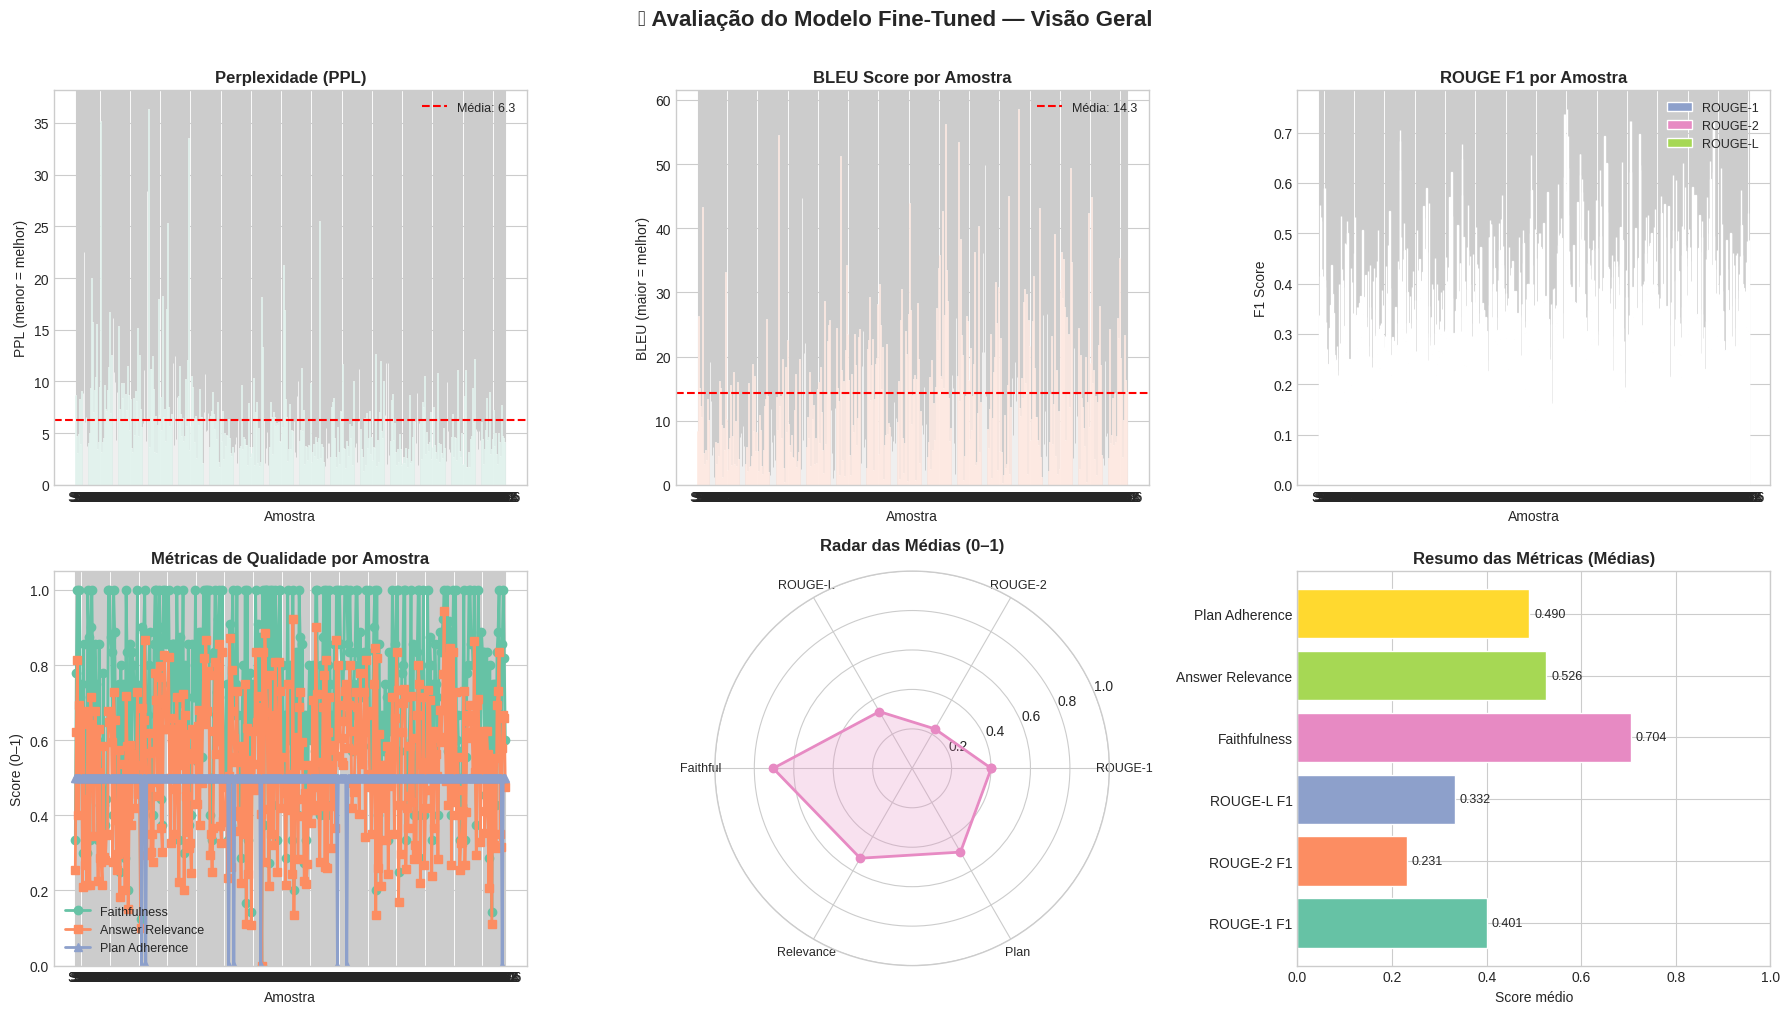

✅ Figura salva em avaliacao_metricas.png


In [15]:
# ============================================================
#  VISUALIZAÇÕES
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 Avaliação do Modelo Fine-Tuned — Visão Geral', fontsize=16, fontweight='bold', y=1.01)

sample_labels = [f'S{i+1}' for i in range(len(samples))]
colors = plt.cm.Set2.colors

# --- 1. Perplexidade por Amostra ---
ax = axes[0, 0]
bars = ax.bar(sample_labels, ppl_scores, color=colors[0], edgecolor='white', linewidth=0.5)
ax.axhline(np.mean(ppl_scores), color='red', linestyle='--', linewidth=1.5, label=f'Média: {np.mean(ppl_scores):.1f}')
ax.set_title('Perplexidade (PPL)', fontweight='bold')
ax.set_ylabel('PPL (menor = melhor)')
ax.set_xlabel('Amostra')
ax.legend(fontsize=9)

# --- 2. BLEU por Amostra ---
ax = axes[0, 1]
ax.bar(sample_labels, bleu_per_sample, color=colors[1], edgecolor='white', linewidth=0.5)
ax.axhline(np.mean(bleu_per_sample), color='red', linestyle='--', linewidth=1.5,
           label=f'Média: {np.mean(bleu_per_sample):.1f}')
ax.set_title('BLEU Score por Amostra', fontweight='bold')
ax.set_ylabel('BLEU (maior = melhor)')
ax.set_xlabel('Amostra')
ax.legend(fontsize=9)

# --- 3. ROUGE F1 Comparativo ---
ax = axes[0, 2]
x = np.arange(len(sample_labels))
w = 0.28
ax.bar(x - w, rouge_f1_1, w, label='ROUGE-1', color=colors[2], edgecolor='white')
ax.bar(x,     rouge_f1_2, w, label='ROUGE-2', color=colors[3], edgecolor='white')
ax.bar(x + w, rouge_f1_L, w, label='ROUGE-L', color=colors[4], edgecolor='white')
ax.set_title('ROUGE F1 por Amostra', fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_xlabel('Amostra')
ax.set_xticks(x)
ax.set_xticklabels(sample_labels)
ax.legend(fontsize=9)

# --- 4. Faithfulness, Relevance, Plan Adherence ---
ax = axes[1, 0]
ax.plot(sample_labels, faithfulness_scores, 'o-', color=colors[0], label='Faithfulness', linewidth=2)
ax.plot(sample_labels, relevance_scores, 's-', color=colors[1], label='Answer Relevance', linewidth=2)
ax.plot(sample_labels, plan_scores, '^-', color=colors[2], label='Plan Adherence', linewidth=2)
ax.set_ylim(0, 1.05)
ax.set_title('Métricas de Qualidade por Amostra', fontweight='bold')
ax.set_ylabel('Score (0–1)')
ax.set_xlabel('Amostra')
ax.legend(fontsize=9)

# --- 5. Radar / Spider Chart das Médias ---
ax = axes[1, 1]
ax.remove()
ax_radar = fig.add_subplot(2, 3, 5, projection='polar')

metric_names  = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'Faithful', 'Relevance', 'Plan']
metric_values = [
    np.mean(rouge_f1_1),
    np.mean(rouge_f1_2),
    np.mean(rouge_f1_L),
    np.mean(faithfulness_scores),
    np.mean(relevance_scores),
    np.mean(plan_scores),
]

angles = np.linspace(0, 2 * np.pi, len(metric_names), endpoint=False).tolist()
values_closed = metric_values + [metric_values[0]]
angles_closed = angles + [angles[0]]

ax_radar.plot(angles_closed, values_closed, 'o-', linewidth=2, color=colors[3])
ax_radar.fill(angles_closed, values_closed, alpha=0.25, color=colors[3])
ax_radar.set_xticks(angles)
ax_radar.set_xticklabels(metric_names, size=9)
ax_radar.set_ylim(0, 1)
ax_radar.set_title('Radar das Médias (0–1)', fontweight='bold', pad=15)

# --- 6. Sumário em barras horizontais ---
ax = axes[1, 2]
summary_names = [
    'ROUGE-1 F1', 'ROUGE-2 F1', 'ROUGE-L F1',
    'Faithfulness', 'Answer Relevance', 'Plan Adherence'
]
summary_vals = metric_values
bar_colors   = [colors[i % len(colors)] for i in range(len(summary_names))]
h_bars = ax.barh(summary_names, summary_vals, color=bar_colors, edgecolor='white')
ax.set_xlim(0, 1)
ax.set_title('Resumo das Métricas (Médias)', fontweight='bold')
ax.set_xlabel('Score médio')
for bar, val in zip(h_bars, summary_vals):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('avaliacao_metricas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva em avaliacao_metricas.png')

## 🔬 Célula 14 — Análise Qualitativa: Comparação Resposta vs. Referência

Examinamos lado a lado as respostas geradas vs. as esperadas para 3 amostras selecionadas.

In [16]:
# ============================================================
#  ANÁLISE QUALITATIVA
# ============================================================

INSPECT_INDICES = [0, 3, 6]   # Altere para ver outras amostras

for idx in INSPECT_INDICES:
    s   = samples[idx]
    gen = generated_responses[idx]

    print('=' * 70)
    print(f'🔎 AMOSTRA {idx + 1}')
    print(f'📌 Instrução : {s["Instruction"]}')
    # Removido: 'input' não existe mais nos dados
    # if s['input']:
    #     print(f'📥 Contexto  : {s["input"]}')
    print()
    print('✅ REFERÊNCIA:')
    print(s["Output"])
    print()
    print('🤖 GERADO:')
    print(gen if gen else '[sem saída gerada]')
    print()
    print(f'   PPL              = {ppl_scores[idx]:.2f}')
    print(f'   BLEU             = {bleu_per_sample[idx]:.2f}')
    print(f'   ROUGE-L F1       = {rouge_f1_L[idx]:.3f}')
    print(f'   Faithfulness     = {faithfulness_scores[idx]:.3f}')
    print(f'   Answer Relevance = {relevance_scores[idx]:.3f}')
    print(f'   Plan Adherence   = {plan_scores[idx]:.3f}')
    print()

🔎 AMOSTRA 1
📌 Instrução : Qual é a principal característica técnica abordada no manual para sistemas de comandos de segurança?

✅ REFERÊNCIA:
O manual aborda principalmente as características técnicas necessárias para o projeto e instalação de sistemas de comandos de segurança em máquinas e equipamentos, enfocando tanto sistemas simples quanto redundantes com dois canais, conforme a Norma Regulamentadora nº 12 (NR-12).

🤖 GERADO:
Os sistemas de comandos de segurança incluem a abertura de portas para abrir e fechar e desligar o motor M1, garantindo a segurança.

   PPL              = 8.65
   BLEU             = 8.37
   ROUGE-L F1       = 0.225
   Faithfulness     = 0.333
   Answer Relevance = 0.255
   Plan Adherence   = 0.500

🔎 AMOSTRA 4
📌 Instrução : Qual é o objetivo principal da revisão mencionada no manual?

✅ REFERÊNCIA:
O objetivo principal da revisão foi permitir a aplicação de várias tecnologias em máquinas e equipamentos, desde que atendam aos requisitos definidos no item 12.4.

## 📝 Célula 15 — Relatório Final

Geração automática de um relatório de texto com interpretação dos resultados.

In [17]:
# ============================================================
#  RELATÓRIO FINAL AUTOMÁTICO
# ============================================================

def interpret(metric: str, value: float) -> str:
    thresholds = {
        'rouge'       : [(0.5, '🟢 Bom'), (0.3, '🟡 Moderado'), (0, '🔴 Fraco')],
        'faith_rel_pl': [(0.7, '🟢 Bom'), (0.4, '🟡 Moderado'), (0, '🔴 Fraco')],
        'bleu'        : [(30,  '🟢 Bom'), (15,  '🟡 Moderado'), (0, '🔴 Fraco')],
    }
    key = 'bleu' if metric == 'bleu' else (
          'rouge' if 'rouge' in metric else 'faith_rel_pl'
    )
    for threshold, label in thresholds[key]:
        if value >= threshold:
            return label
    return '🔴 Fraco'

mean_r1 = np.mean(rouge_f1_1)
mean_r2 = np.mean(rouge_f1_2)
mean_rL = np.mean(rouge_f1_L)
mean_bl = np.mean(bleu_per_sample)
mean_fa = np.mean(faithfulness_scores)
mean_re = np.mean(relevance_scores)
mean_pl = np.mean(plan_scores)

print('=' * 65)
print('         📋  RELATÓRIO DE AVALIAÇÃO — MODELO FINE-TUNED')
print('=' * 65)
#print(f'  Modelo Base     : distilgpt2')
print(f'  Modelo Base     : {MODEL_BASE}')
print(f'  Adaptador       : LoRA  ({LORA_MODEL_PATH})')
print(f'  Dataset         : {DATASET_PATH}  ({len(samples)} amostras)')
print(f'  Dispositivo     : {DEVICE}')
print('=' * 65)
print()
print(f'  PERPLEXIDADE (PPL)')
print(f'    Média : {np.mean(ppl_scores):.2f}  —  PPL menor = modelo mais previsível')
print()
print(f'  BLEU')
print(f'    Corpus Score : {bleu_results["bleu_score"]:.2f}  {interpret("bleu", bleu_results["bleu_score"])}')
print(f'    Média por amostra : {mean_bl:.2f}')
print()
print(f'  ROUGE')
print(f'    ROUGE-1 F1 : {mean_r1:.3f}  {interpret("rouge1", mean_r1)}')
print(f'    ROUGE-2 F1 : {mean_r2:.3f}  {interpret("rouge2", mean_r2)}')
print(f'    ROUGE-L F1 : {mean_rL:.3f}  {interpret("rougeL", mean_rL)}')
print()
print(f'  FIDELIDADE (FAITHFULNESS)')
print(f'    Média : {mean_fa:.3f}  {interpret("faithfulness", mean_fa)}')
print()
print(f'  RELEVÂNCIA DA RESPOSTA (ANSWER RELEVANCE)')
print(f'    Média : {mean_re:.3f}  {interpret("relevance", mean_re)}')
print()
print(f'  ADERÊNCIA AO PLANO (PLAN ADHERENCE)')
print(f'    Média : {mean_pl:.3f}  {interpret("plan", mean_pl)}')
print()
print('─' * 65)
print('  💡 ANÁLISE GLOBAL:')
print(f'     O modelo apresenta PPL={np.mean(ppl_scores):.1f}, indicando',
      'boa' if np.mean(ppl_scores) < 50 else 'moderada', 'fluência.')
print(f'     As métricas de sobreposição léxica (BLEU/ROUGE) refletem')
print(f'     o grau de fidelidade ao texto de referência.')
print(f'     Faithfulness={mean_fa:.2f} e Plan Adherence={mean_pl:.2f} indicam')
print(f'     se o modelo é adequado para pipelines RAG e agentes.')
print('=' * 65)

         📋  RELATÓRIO DE AVALIAÇÃO — MODELO FINE-TUNED
  Modelo Base     : unicamp-dl/ptt5-v2-base
  Adaptador       : LoRA  (lora_finetuned_model)
  Dataset         : /content/dataset.jsonl  (416 amostras)
  Dispositivo     : cuda

  PERPLEXIDADE (PPL)
    Média : 6.26  —  PPL menor = modelo mais previsível

  BLEU
    Corpus Score : 15.64  🟡 Moderado
    Média por amostra : 14.27

  ROUGE
    ROUGE-1 F1 : 0.401  🟡 Moderado
    ROUGE-2 F1 : 0.231  🔴 Fraco
    ROUGE-L F1 : 0.332  🟡 Moderado

  FIDELIDADE (FAITHFULNESS)
    Média : 0.704  🟢 Bom

  RELEVÂNCIA DA RESPOSTA (ANSWER RELEVANCE)
    Média : 0.526  🟡 Moderado

  ADERÊNCIA AO PLANO (PLAN ADHERENCE)
    Média : 0.490  🟡 Moderado

─────────────────────────────────────────────────────────────────
  💡 ANÁLISE GLOBAL:
     O modelo apresenta PPL=6.3, indicando boa fluência.
     As métricas de sobreposição léxica (BLEU/ROUGE) refletem
     o grau de fidelidade ao texto de referência.
     Faithfulness=0.70 e Plan Adherence=0.49 indic

## 💾 Célula 16 — Exportar Resultados

Salvamos os resultados detalhados em CSV e o gráfico em PNG.

In [18]:
# ============================================================
#  EXPORTAR RESULTADOS
# ============================================================

# CSV detalhado com respostas geradas
df_export = df_results.copy()
df_export['Gerado']    = generated_responses
df_export['Referência'] = reference_outputs

CSV_PATH = 'resultados_avaliacao.csv'
df_export.to_csv(CSV_PATH, index=False, encoding='utf-8-sig')

print(f'✅ Resultados exportados:')
print(f'   📄 {CSV_PATH}           — métricas por amostra + textos')
print(f'   🖼️  avaliacao_metricas.png — visualizações')
print()
print('🎉 Avaliação concluída! Todos os artefatos foram gerados.')

✅ Resultados exportados:
   📄 resultados_avaliacao.csv           — métricas por amostra + textos
   🖼️  avaliacao_metricas.png — visualizações

🎉 Avaliação concluída! Todos os artefatos foram gerados.


---

## 📚 Referências e Próximos Passos

### Referências
| Recurso | Link |
|---|---|
| BLEU original | Papineni et al., 2002 |
| ROUGE original | Lin, 2004 |
| Perplexidade | Jelinek et al., 1977 |
| RAGAs (Faithfulness/Relevance) | [github.com/explodinggradients/ragas](https://github.com/explodinggradients/ragas) |
| LoRA | Hu et al., 2021 |

### Próximos Passos Sugeridos

1. **Faithfulness com NLI**: substituir a abordagem léxica por um modelo DeBERTa treinado em NLI.
2. **LLM-as-judge**: usar GPT-4 ou Claude para avaliar Relevância e Plan Adherence de forma semântica.
3. **RAGAs**: integrar o framework [RAGAs](https://github.com/explodinggradients/ragas) para avaliação automatizada de pipelines RAG.
4. **Comparação baseline**: avaliar o `distilgpt2` sem LoRA e comparar com o fine-tuned para quantificar o ganho.
5. **Human Evaluation**: coletar avaliações humanas para validar as métricas automáticas.